#Introduction

#### The data evaluates women's fertility in the 1980s in the United States. The women are between the ages of 21-35 who are married. The cross-section data determine whether married women who have two or more children want more. The research examines the relationship between demographic characteristics, economic factors, and family strucutre as variables that influence ferliity outcomes. This analysis is particularly valuable for understanding historical fertility trends and inform present day social policies, healthcare planning, and more in depth demographic research.
#### A data frame containing 254,654 observations on 8 variables and 1 rowname. The eight variables are: gender1 and gender 2 (for each child), age (mother), afam (mother African American), hispanic (mother is hispanic), other (race and ethnicity), and work (number of weeks worked in 1979). The target variable for supervised learning is whether a married woman has two or more children. This is a binary classification target.




###Key Research Context:
####• Time Period: 1980s United States.
####• Population: Married women aged 21-35 years.
####• Focus: Factors influencing decision to have 2+ children.
####• Analysis: Investigating differential effects of age, race/ethnicity, employment, and existing family structures on the likelihood of having more than two children.

In [ ]:
import pandas as pd

df = pd.read_csv('/content/Fertility.csv')

print ("Data Overview")
print(f"• Total Observations: {df.shape[0]:,}")
print(f"• Total Variables: {df.shape[1]}")
print(f"• Data Type: Cross-sectional survey data")
print(f"• Analysis Type: Binary classification (supervised learning)")

Data Overview
• Total Observations: 254,654
• Total Variables: 9
• Data Type: Cross-sectional survey data
• Analysis Type: Binary classification (supervised learning)


#### Get and Read Dataset

In [ ]:
from google.colab import drive
import os

# 1. Mount Google Drive
drive.mount('/content/drive')


file_path_in_drive = '/content/drive/My Drive/Fertility.csv'

# Define the destination path in your Colab environment
destination_path_in_colab = '/content/Fertility.csv'

# 2. Check if the file exists in Google Drive (optional but recommended)
if os.path.exists(file_path_in_drive):
    !cp "{file_path_in_drive}" "{destination_path_in_colab}"
    print(f"File copied to {destination_path_in_colab}")
else:
    print(f"File not found at {file_path_in_drive}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
File copied to /content/Fertility.csv


#### Data Cleaning

In [ ]:
import pandas as pd

# Load the dataset into a pandas DataFrame
df = pd.read_csv('/content/Fertility.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

#Handle missing values
print(df.isnull().sum())




,rownames,morekids,gender1,gender2,age,afam,hispanic,other,work
0,1,no,male,female,27,no,no,no,0
1,2,no,female,male,30,no,no,no,30
2,3,no,male,female,27,no,no,no,0
3,4,no,male,female,35,yes,no,no,0
4,5,no,female,female,30,no,no,no,22


rownames    0
morekids    0
gender1     0
gender2     0
age         0
afam        0
hispanic    0
other       0
work        0
dtype: int64


####Pre-Procesing


In [ ]:
import pandas as pd
import numpy as np
from sklearn import tree
from sklearn import metrics

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

#Machine Learning Libabries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression


from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# Evaluation Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                            f1_score, confusion_matrix, classification_report,
                            roc_auc_score, roc_curve, balanced_accuracy_score)

# Statistical Tests
from scipy.stats import chi2_contingency, ttest_ind
import scipy.stats as stats


# Statistical Tests
from scipy.stats import chi2_contingency, ttest_ind
import scipy.stats as stats

# Used AI to ask about what libraries would be best to import for the datatset
#based on my intial thoughts on what graphs and visual tools I want to use


In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd # Import pandas if not already imported in a preceding cell

# The 'morekids' is the target variable and other columns are features
# Define features (X) and target (y)
# Drop 'rownames' as an identifier
X = df.drop(['morekids', 'rownames'], axis=1)
y = df['morekids']

# Split the data into training and testing sets
# Use a test size of 20% and a random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape (X_train, y_train):", X_train.shape, y_train.shape)
print("Testing set shape (X_test, y_test):", X_test.shape, y_test.shape)

Training set shape (X_train, y_train): (203723, 7) (203723,)
Testing set shape (X_test, y_test): (50931, 7) (50931,)


#### Missing Values

In [ ]:
COLUMNS = 1
INDEX = 0

In [ ]:
# Missing Value Table
missing_summary = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100,
    'Has_Missing_Data': df.isnull().sum() > 0,  # True (yes) or False (no)

})

print("Detailed missing value report:")
print(missing_summary)



Detailed missing value report:
            Column  Missing_Count  Missing_Percentage  Has_Missing_Data
rownames  rownames              0                 0.0             False
morekids  morekids              0                 0.0             False
gender1    gender1              0                 0.0             False
gender2    gender2              0                 0.0             False
age            age              0                 0.0             False
afam          afam              0                 0.0             False
hispanic  hispanic              0                 0.0             False
other        other              0                 0.0             False
work          work              0                 0.0             False


#### Duplicate Values

In [ ]:
# Calculate duplicate count and percentage
duplicate_count = df.duplicated().sum()
duplicate_percentage = (duplicate_count / len(df)) * 100

# Duplicate Value Table
duplicate_summary = pd.DataFrame({
    'Check_Type': ['Exact Row Duplicates', 'Unique Rows', 'Total Rows'],
    'Count': [duplicate_count, len(df) - duplicate_count, len(df)],
    'Percentage': [duplicate_percentage, 100 - duplicate_percentage, 100.0]
})

print("Duplicate Summary:")
print(duplicate_summary)

Duplicate Summary:
             Check_Type   Count  Percentage
0  Exact Row Duplicates       0         0.0
1           Unique Rows  254654       100.0
2            Total Rows  254654       100.0


#Exploratory Analysis

####Imbalances

In [ ]:
# Calculate counts and percentages for the target variable 'morekids'
target_counts = df['morekids'].value_counts()
target_percentages = df['morekids'].value_counts(normalize=True) * 100

# Determine majority and minority class percentages
majority_class_percent = target_percentages.max()
minority_class_percent = target_percentages.min()


# Balance table
balance_summary = pd.DataFrame({
    'Category': target_counts.index,
    'Count': target_counts.values,
    'Percentage': target_percentages.values,
    'Status': ['Majority' if p == majority_class_percent else 'Minority'
               for p in target_percentages.values]
})

print("Detailed Balance Summary:")
print(balance_summary)

# Calculate imbalance ratio
imbalance_ratio = majority_class_percent / minority_class_percent
print(f"\nImbalance Ratio: {imbalance_ratio:.2f}:1")
print(f"(For every 1 minority example, there are {imbalance_ratio:.1f} majority examples)")

if imbalance_ratio <= 1.5:
    ratio_status = "Excellent ratio"
elif imbalance_ratio <= 2.0:
    ratio_status = "Good ratio"
elif imbalance_ratio <= 3.0:
    ratio_status = "Moderate imbalance"
elif imbalance_ratio <= 9.0:
    ratio_status = "High imbalance"
else:
    ratio_status = "Extreme imbalance"


print(f"Ratio Assessment: {ratio_status}")

Detailed Balance Summary:
  Category   Count  Percentage    Status
0       no  157742   61.943657  Majority
1      yes   96912   38.056343  Minority

Imbalance Ratio: 1.63:1
(For every 1 minority example, there are 1.6 majority examples)
Ratio Assessment: Good ratio


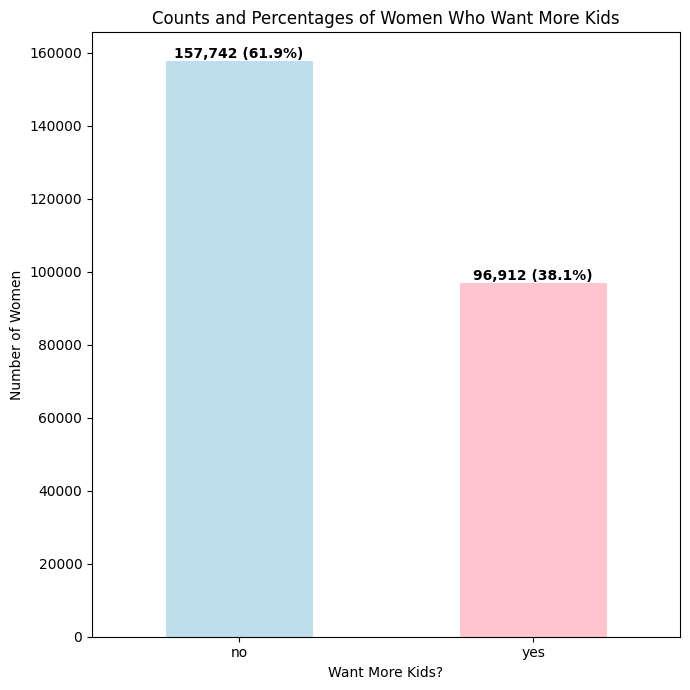

In [ ]:
# Create a figure and a single subplot for the bar chart
fig, ax = plt.subplots(1, 1, figsize=(7, 7)) # Adjust figure size as needed

# --- Visualization: Bar Chart of Target Variable Counts with Percentages ---
# Plot the counts of each category in the target variable ('morekids') as a bar chart
target_counts.plot(kind='bar', ax=ax, color=['lightblue', 'lightpink'], alpha=0.8)

# Set the title and labels for the chart
ax.set_title('Counts and Percentages of Women Who Want More Kids') # Descriptive title
ax.set_ylabel('Number of Women') # Label for the y-axis
ax.set_xlabel('Want More Kids?') # Label for the x-axis
ax.tick_params(axis='x', rotation=0) # Keep x-axis labels horizontal

# Add the count and percentage numbers on top of each bar for clarity
total = len(df) # Get the total number of observations
for i, (label, count) in enumerate(target_counts.items()):
    percentage = (count / total) * 100
    # Place the text slightly above the bar, displaying both count and percentage
    ax.text(i, count + len(df)*0.0005, f'{count:,} ({percentage:.1f}%)',
                ha='center', va='bottom', fontweight='bold')


# Adjust subplot parameters to give a tight layout automatically
plt.tight_layout()

# Display the plot
plt.show()



#Used AI to help create the best most efficient for loop by using enumerate for number and percentage representative above each bar.
#It allows the user to loop over something and have an automatic counter.
#It also also accepts an optional argument that allows a person to specify the starting index of the counter.

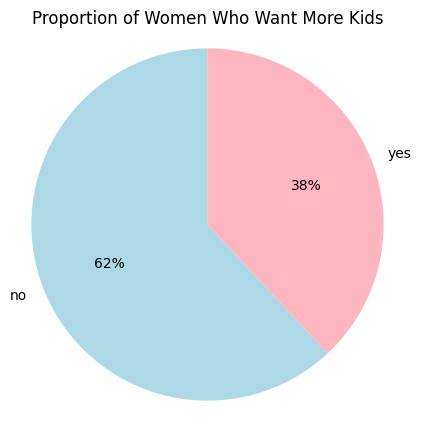

In [ ]:
#Pie Chart

# Calculate the counts of each category in the 'morekids' column
morekids_counts = df['morekids'].value_counts()

# Create a pie chart
plt.figure(figsize=(5, 5)) # Adjust figure size as needed
plt.pie(morekids_counts, labels=morekids_counts.index, autopct='%1.0f%%', startangle=90, colors=['lightblue', 'lightpink'])

# Add a title
plt.title('Proportion of Women Who Want More Kids')

# Ensure the pie chart is a circle
plt.axis('equal')

# Show the plot
plt.show()

#### Do Women Want More Than Two Children?

##### When it comes to having more children aroubd 62% did not want more, and 38% said they wanted more children.  

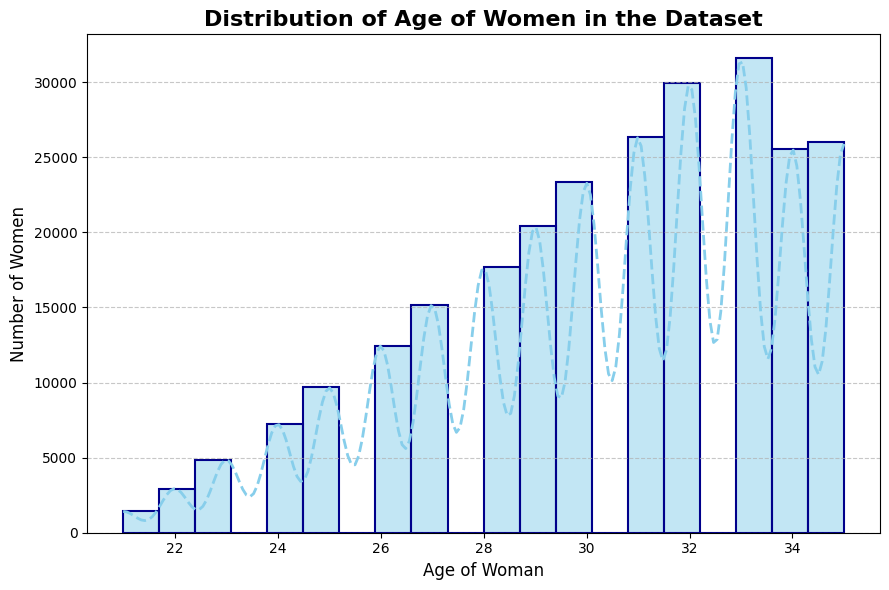

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set the size of the plot figure. (width, height in inches)
plt.figure(figsize=(9, 6))

# Use histplot with adjusted edge color and linewidth for better visibility
# Also adjust KDE line style
sns.histplot(x='age', data=df, bins=20, kde=True, color='skyblue', edgecolor='darkblue', linewidth=1.5,
             line_kws={'color': 'black', 'linewidth': 2, 'linestyle': '--'}) # Adjust KDE line style to black

# Set the main title of the plot.
plt.title('Distribution of Age of Women in the Dataset', fontsize=16, fontweight='bold')

# Set the label for the horizontal (x) axis.
plt.xlabel('Age of Woman', fontsize=12)

# Set the label for the vertical (y) axis.
plt.ylabel('Number of Women', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()





#### The Age of the Women

##### Most women were around the age of 30-34 and the minority were those ages younger than 22.

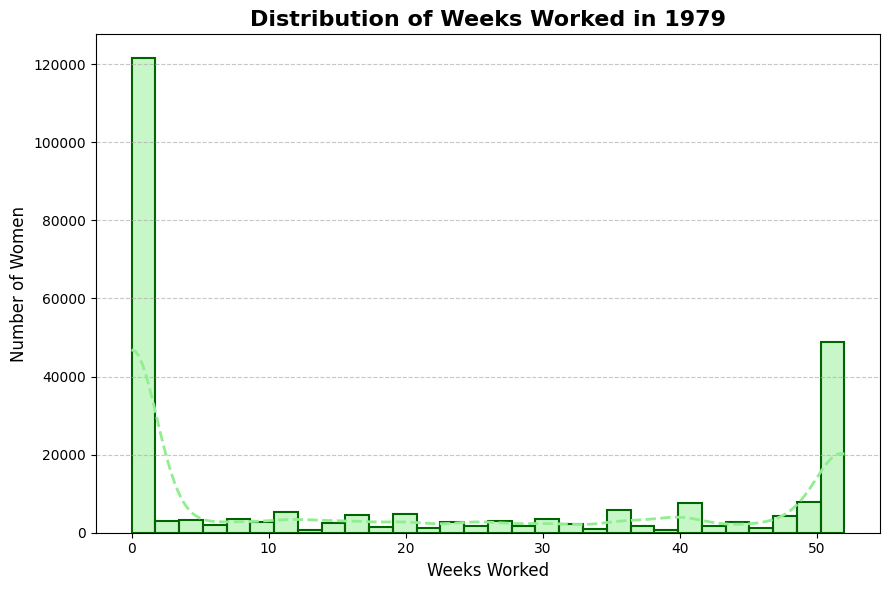

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create histogram for the 'work' column
plt.figure(figsize=(9, 6))
sns.histplot(x='work', data=df, bins=30, kde=True, color='lightgreen', edgecolor='darkgreen', linewidth=1.5,
             line_kws={'color': 'black', 'linewidth': 2, 'linestyle': '--'})

plt.title('Distribution of Weeks Worked in 1979', fontsize=16, fontweight='bold')
plt.xlabel('Weeks Worked', fontsize=12)
plt.ylabel('Number of Women', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

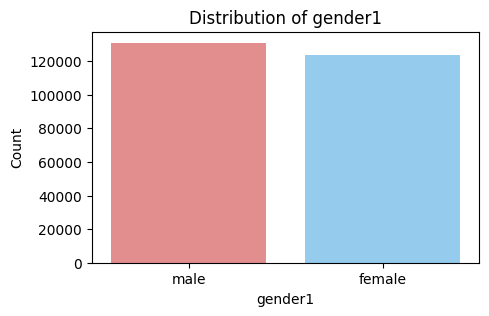

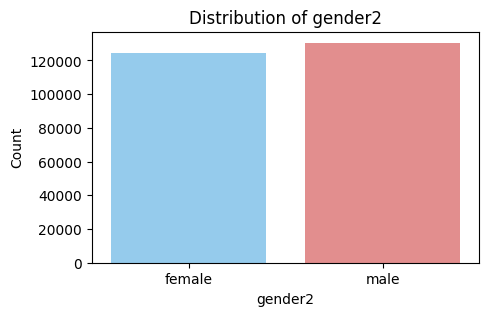

In [ ]:
# Import necessary libraries for plotting
import seaborn as sns # Seaborn is great for making nice-looking statistical plots
import matplotlib.pyplot as plt # Matplotlib is the foundation for plotting in Python

# List of the categorical columns we want to create plots for
# These are the columns related to the gender of the children
categorical_cols_gender = ['gender1', 'gender2']

# Define specific colors for male and female bars in the plots
# We are creating a dictionary where the keys are the categories ('male', 'female')
# and the values are the color names we want to use
gender_colors = {'male': 'lightcoral', 'female': 'lightskyblue'} # lightcoral for male, lightskyblue for female

# Loop through each column name in our list (categorical_cols_gender)
# In each turn of the loop, 'col' will be either 'gender1' or 'gender2'
for col in categorical_cols_gender:
    # Create a new figure (a blank canvas) for each plot
    # figsize=(5, 3) sets the width to 5 inches and height to 3 inches
    plt.figure(figsize=(5, 3))

    # Create a count plot using seaborn
    # A count plot shows the number of occurrences of each category
    # 'data=df' tells seaborn to use our DataFrame named 'df' (where our data is stored)
    # 'x=col' tells seaborn to put the current column's categories ('male', 'female') on the x-axis
    # 'hue=col' tells seaborn to color the bars based on the categories in this column (which is the same as x)
    # 'palette=gender_colors' tells seaborn to use the colors we defined for male and female
    # 'legend=False' hides the legend since the colors are directly on the bars
    sns.countplot(data=df, x=col, hue=col, palette=gender_colors, legend=False)

    # Set the title of the plot
    # f'Distribution of {col}' creates a title like "Distribution of gender1" or "Distribution of gender2"
    plt.title(f'Distribution of {col}')

    # Set the label for the x-axis
    plt.xlabel(col) # The x-axis label will be the column name (e.g., 'gender1')

    # Set the label for the y-axis (which represents the count of each category)
    plt.ylabel('Count')

    # Display the plot for the current column
    plt.show()

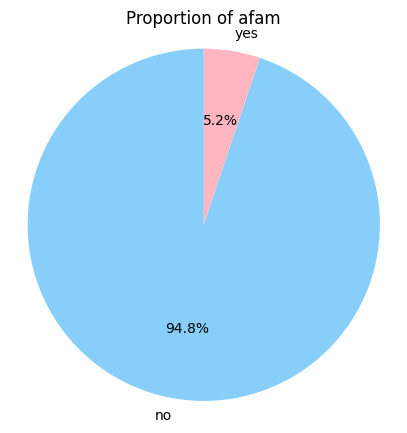

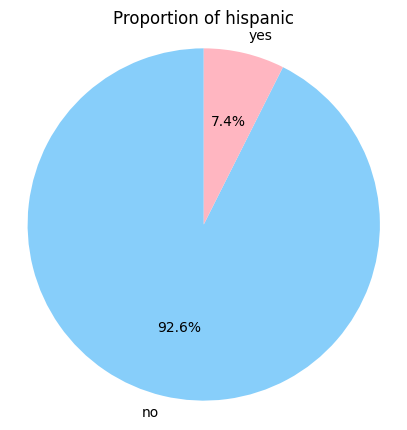

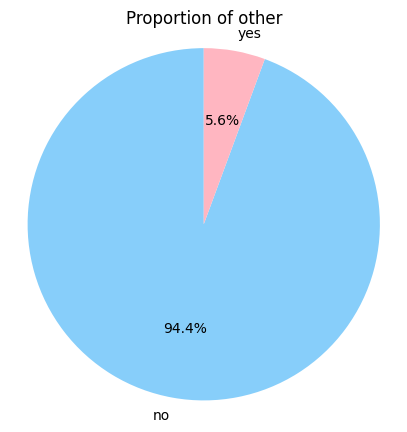

In [ ]:
import matplotlib.pyplot as plt

# List of the categorical columns to plot as pie charts
categorical_cols_race_ethnicity = ['afam', 'hispanic', 'other']

# Loop through each column
for col in categorical_cols_race_ethnicity:
    # Calculate the counts for each category
    counts = df[col].value_counts()

    # Create a figure for the pie chart
    plt.figure(figsize=(5, 5))

    # Create a pie chart
    plt.pie(counts.values, labels=counts.index, autopct='%1.1f%%', startangle=90, colors=['lightskyblue', 'lightpink']) # Using different colors

    # Add a title
    plt.title(f'Proportion of {col}')

    # Ensure the pie chart is a circle
    plt.axis('equal')

    # Show the plot
    plt.show()

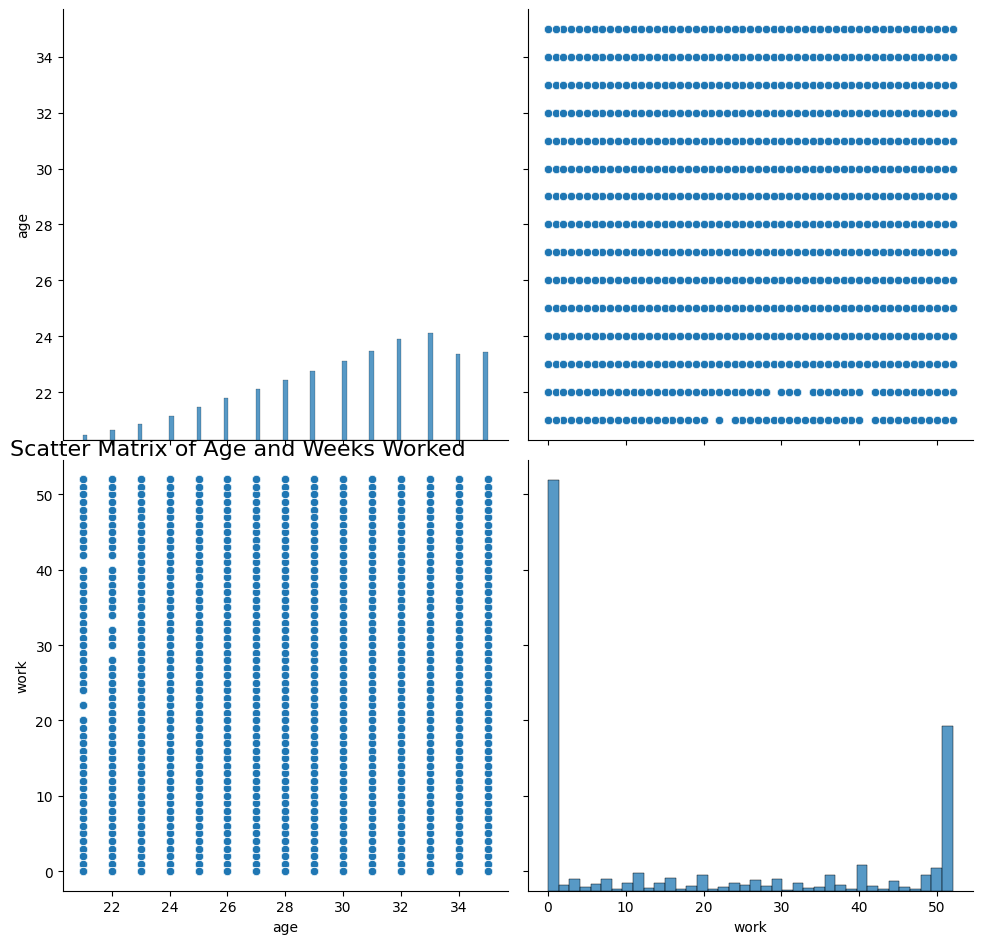

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a scatter matrix (pair plot) for numerical columns
# Use 'age' and 'work' as the numerical columns
numerical_cols = ['age', 'work']

# 'data=df' specifies the DataFrame
# 'vars=numerical_cols' specifies the columns to include in the plot
sns.pairplot(data=df, vars=numerical_cols)

# Add a title to the overall figure (optional, pairplot doesn't have a built-in title)
plt.suptitle('Scatter Matrix of Age and Weeks Worked', y=1.02, fontsize=16) # Adjust y for title position

plt.tight_layout(rect=[0, 0, 2, 1.98]) # Adjust layout to make space for suptitle
plt.show()

In [ ]:
# Calculate the average weeks worked for each racial/ethnic group
average_work_by_race_ethnicity = df.groupby(['afam', 'hispanic', 'other'])['work'].mean().reset_index()

print("Average Weeks Worked by Race/Ethnicity:")
print(average_work_by_race_ethnicity)

Average Weeks Worked by Race/Ethnicity:
  afam hispanic other       work
0   no       no    no  18.406225
1   no       no   yes  21.353046
2   no      yes    no  18.061258
3   no      yes   yes  18.341904
4  yes       no    no  29.169290
5  yes      yes    no  22.372449


#### Scatter Matrix Interpretation

The scatter matrix of 'age' and 'work' shows the distribution of each variable on the diagonal and the scatter plot of the pair on the off-diagonal.

*   **Diagonal Plots (Histograms):** These show the individual distribution of 'age' and 'work'. The histogram for 'age' indicates a fairly uniform distribution of women across the age range of 21-35, with slightly higher counts in the later years. The histogram for 'work' shows a bimodal distribution with a large peak at 0 weeks worked and another peak around 50-52 weeks worked. This suggests a significant portion of women in the dataset either did not work or worked full-time in 1979.

*   **Off-Diagonal Plots (Scatter Plots):** The scatter plots show the relationship between 'age' and 'work'. There isn't a clear linear correlation between age and weeks worked. The data points are clustered, reflecting the bimodal distribution of 'work' across all age groups. This suggests that whether a woman worked and how many weeks she worked in 1979 was not strongly dependent on her age within this age range.

####Boxplots

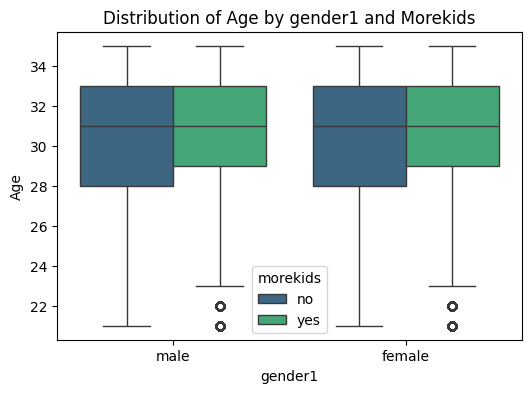

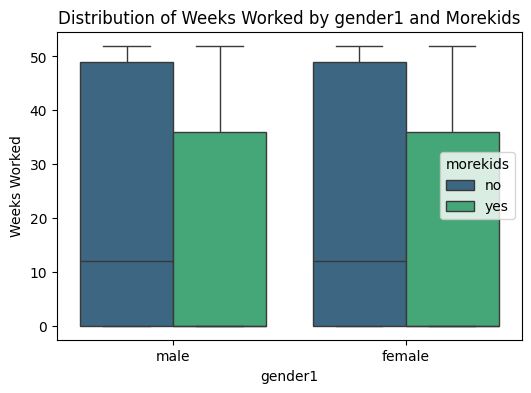

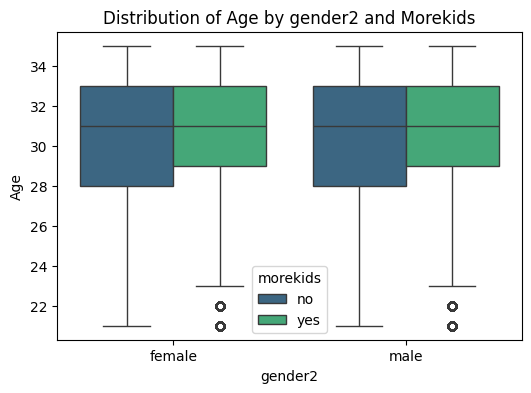

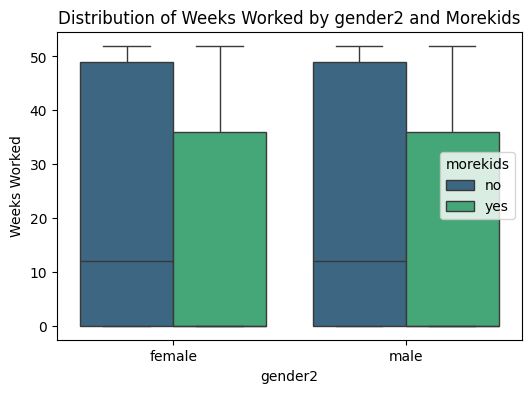

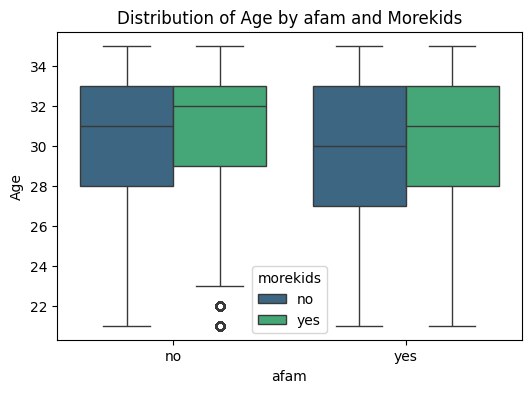

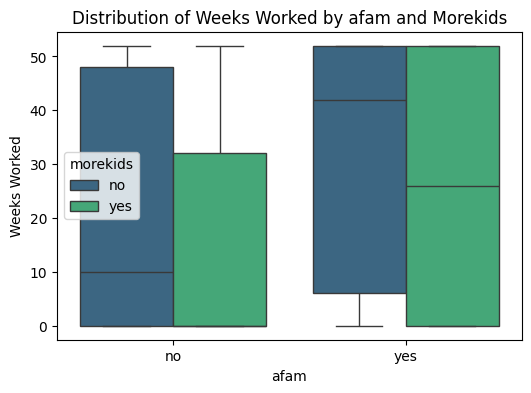

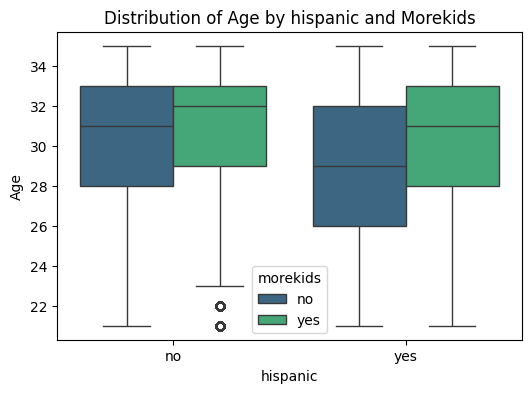

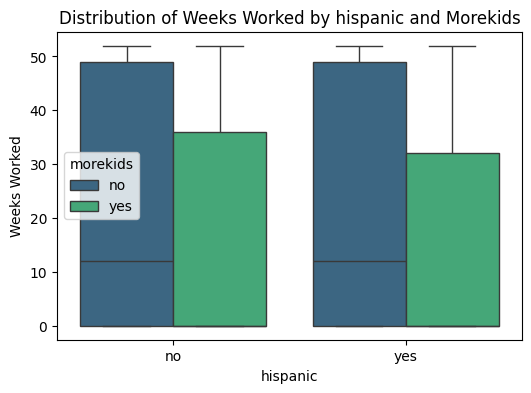

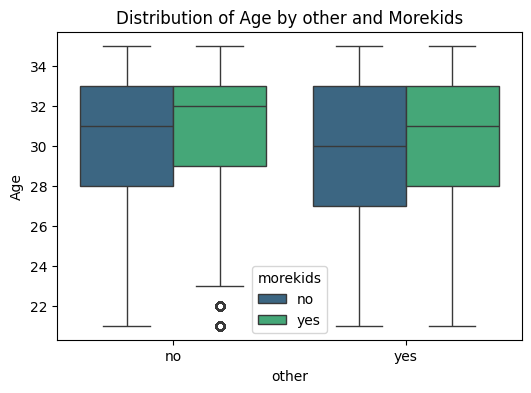

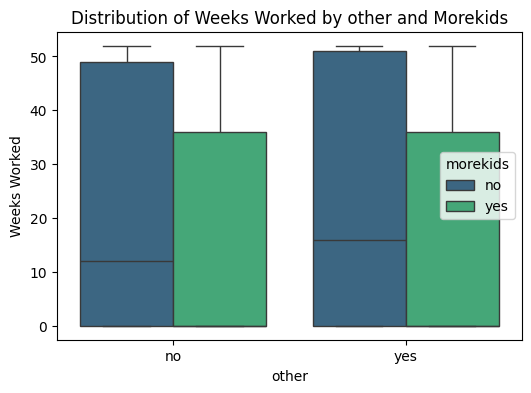

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# List of categorical columns to plot against 'morekids'
categorical_cols = ['gender1', 'gender2', 'afam', 'hispanic', 'other']

# Create boxplots for each categorical column against the target variable
for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x=col, y='age', hue='morekids', palette='viridis')
    plt.title(f'Distribution of Age by {col} and Morekids')
    plt.xlabel(col)
    plt.ylabel('Age')
    plt.show()

    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x=col, y='work', hue='morekids', palette='viridis')
    plt.title(f'Distribution of Weeks Worked by {col} and Morekids')
    plt.xlabel(col)
    plt.ylabel('Weeks Worked')
    plt.show()

#### Boxplot Interpretations

*   **Gender of Children (gender1, gender2):** The boxplots for `gender1` and `gender2` show very little difference in the distribution of age and weeks worked based on the gender of the first or second child and whether the woman wants more kids. This suggests that the gender of the existing children may not be a strong predictor of wanting more kids in this dataset.

*   **Race/Ethnicity (afam, hispanic, other):**
    *   **Age:** The boxplots for `afam`, `hispanic`, and `other` show some subtle differences in the age distribution across the different racial/ethnic groups, but the overall range and median age are similar for both 'yes' and 'no' in wanting more kids within each group.
    *   **Weeks Worked:** The boxplots for weeks worked show more distinct patterns. For all racial/ethnic categories, women who do not want more kids ('no') tend to have a higher median number of weeks worked compared to those who do want more kids ('yes'). This is particularly noticeable for the 'no' groups across all race/ethnicity categories, indicating that employment status might play a role in the decision to have more children.

Overall, the boxplots suggest that while the gender of existing children might not be a key factor, race/ethnicity and employment status could have some influence on whether a woman wants more children.

#### Heatmap for Correlation Analysis


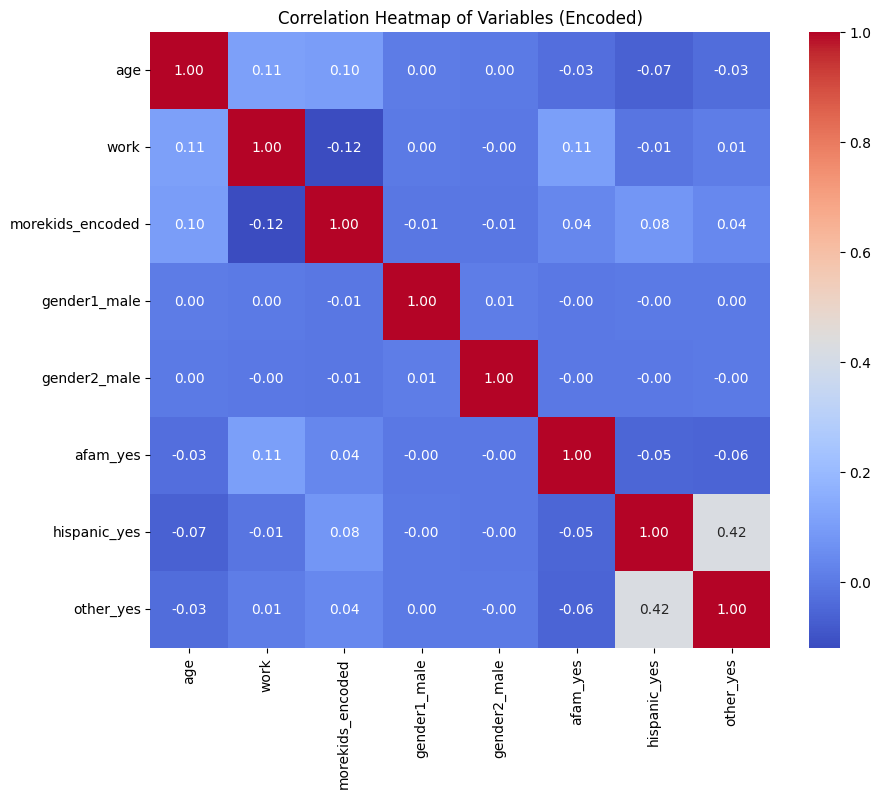

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Re-load the data to ensure we have the original categorical columns
df_encoded = df.copy()

# Label Encode the target variable 'morekids'
label_encoder = LabelEncoder()
df_encoded['morekids_encoded'] = label_encoder.fit_transform(df_encoded['morekids'])

# One-Hot Encode the categorical features
categorical_cols_for_encoding = ['gender1', 'gender2', 'afam', 'hispanic', 'other']
df_encoded = pd.get_dummies(df_encoded, columns=categorical_cols_for_encoding, drop_first=True)

# Drop the original 'morekids' column and 'rownames' as they are no longer needed for correlation
df_encoded = df_encoded.drop(['morekids', 'rownames'], axis=1)


# Calculate the correlation matrix
correlation_matrix = df_encoded.corr()

# Create a heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Variables (Encoded)')
plt.show()

#### Heatmap Interpretation

The heatmap shows the pairwise correlation coefficients between all the variables, including the one-hot encoded categorical features and the encoded target variable ('morekids_encoded').

*   **Target Variable Correlation:** Focus on the row/column corresponding to `morekids_encoded`. The correlation values here indicate the strength and direction of the linear relationship between each variable and the likelihood of wanting more kids.
    *   'work' appears to have a negative correlation with 'morekids_encoded'. This aligns with the boxplot observations, suggesting that women who worked more weeks in 1979 were less likely to want more children.
    *   'age' seems to have a weak negative correlation with 'morekids_encoded', implying that older women in this age range might be slightly less likely to want more children, though this relationship is not strong.
    *   The one-hot encoded race/ethnicity variables (`afam_yes`, `hispanic_yes`, `other_yes`) show relatively weak correlations with the target variable, although `afam_yes` and `hispanic_yes` have slight positive correlations, suggesting a very minor association with wanting more kids for these groups compared to the reference group.
    *   The gender variables (`gender1_male`, `gender2_male`) have very close-to-zero correlations with `morekids_encoded`, further supporting the idea that the gender of existing children is not a strong predictor.

*   **Inter-Feature Correlation:** The heatmap also shows the correlation between the features themselves. For example, the correlations between the one-hot encoded race/ethnicity variables are negative, which is expected as a woman can only belong to one of these categories. There are no strong correlations between 'age' and 'work' or between 'age'/'work' and the race/ethnicity/gender variables, which suggests these features are relatively independent of each other.

Overall, the heatmap reinforces the idea that 'work' and possibly 'age' are the most notable factors among the given variables that might influence a woman's decision to have more children, while the gender of existing children appears to have very little impact.

#### Hypothesis

Based on the exploratory data analysis, particularly the boxplots and the correlation heatmap, a plausible hypothesis is:

**Hypothesis:** Married women aged 21-35 in the United States in the 1980s who were employed (worked more weeks in 1979) were less likely to want more than two children compared to those who were not employed. Additionally, age might have a minor negative influence on the desire for more children within this age group, while the gender of existing children is not a significant factor. The racial/ethnic background might have a very weak association, but employment status appears to be a more prominent influencing factor among the variables examined.

####Predictive Analysis

##### Model Selection and Training

1.  **Logistic Regression:** A simple linear model that is a good baseline.
2.  **Decision Tree Classifier:** A tree-based model that is easy to interpret.
3.  **Random Forest Classifier:** An ensemble of decision trees that generally performs well.
4.  **K-Nearest Neighbors Classifier:** A non-parametric model that classifies based on the majority class of nearest neighbors.

In [ ]:
# Logistic Regression Model
print("--- Logistic Regression ---")
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # liblinear is good for small datasets and binary classification
log_reg_model.fit(X_train_processed, y_train) # Use the preprocessed training data

# Predictions
y_pred_log_reg = log_reg_model.predict(X_test_processed) # Use the preprocessed testing data for prediction
y_train_pred_log_reg = log_reg_model.predict(X_train_processed) # Use the preprocessed training data for training accuracy

# Evaluation
recall_log_reg = recall_score(y_test, y_pred_log_reg, pos_label='yes') # Specify pos_label for non-numerical target
precision_log_reg = precision_score(y_test, y_pred_log_reg, pos_label='yes') # Specify pos_label for non-numerical target
balanced_accuracy_log_reg = balanced_accuracy_score(y_test, y_pred_log_reg)
train_accuracy_log_reg = log_reg_model.score(X_train_processed, y_train) # Training accuracy with processed data

print(f"Training Accuracy: {train_accuracy_log_reg:.4f}")
print(f"Recall: {recall_log_reg:.4f}")
print(f"Precision: {precision_log_reg:.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_log_reg:.4f}")

# Model Interpretation (Example for Logistic Regression - coefficients)
# Note: Interpreting coefficients after one-hot encoding requires mapping back to original categories
# This part might be more advanced for a beginner, but we can show the coefficients for processed features
print("\nLogistic Regression Coefficients (for processed features):")
# Get feature names after preprocessing
ohe_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
all_feature_names = numerical_cols + ohe_feature_names.tolist()

for feature, coef in zip(all_feature_names, log_reg_model.coef_[0]):
    print(f"{feature}: {coef:.4f}")

--- Logistic Regression ---


NameError: name 'X_train_processed' is not defined

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Get the coefficients and feature names from the trained Logistic Regression model
log_reg_coef = trained_models["Logistic Regression"].coef_[0]
# Feature names were already created during preprocessing
# ohe_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
# all_feature_names = numerical_cols.tolist() + ohe_feature_names.tolist()

# Create a pandas Series for easier plotting
coef_series = pd.Series(log_reg_coef, index=all_feature_names)

# Sort coefficients for better visualization
sorted_coef = coef_series.sort_values(ascending=False)

# Create a bar plot of the coefficients
plt.figure(figsize=(10, 6))
sorted_coef.plot(kind='bar', color=sorted_coef.apply(lambda x: 'skyblue' if x > 0 else 'salmon')) # Color positive and negative coefficients differently
plt.title('Logistic Regression Coefficients', fontsize=16)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Coefficient Value', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for readability
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

print("Logistic Regression Coefficients (sorted):")
print(sorted_coef)

In [ ]:
# Decision Tree Classifier Model
print("\n--- Decision Tree Classifier ---")
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5) # Limiting max_depth for easier visualization
dt_model.fit(X_train_processed, y_train) # Use the preprocessed training data

# Predictions
y_pred_dt = dt_model.predict(X_test_processed) # Use the preprocessed testing data
y_train_pred_dt = dt_model.predict(X_train_processed) # Use the preprocessed training data

# Evaluation
# We need to specify the positive label for recall and precision since 'morekids' is not numerical
recall_dt = recall_score(y_test, y_pred_dt, pos_label='yes')
precision_dt = precision_score(y_test, y_pred_dt, pos_label='yes')
balanced_accuracy_dt = balanced_accuracy_score(y_test, y_pred_dt)
train_accuracy_dt = dt_model.score(X_train_processed, y_train) # Training accuracy with processed data

print(f"Training Accuracy: {train_accuracy_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_dt:.4f}")

# Model Visualization (Tree Visualization)
plt.figure(figsize=(20, 10))
# Use the feature names from the preprocessor for the tree visualization
plot_tree(dt_model, filled=True, feature_names=all_feature_names, class_names=['no', 'yes'], rounded=True)
plt.title("Decision Tree Visualization")
plt.show()



In [ ]:
# Random Forest Classifier Model
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, precision_score, balanced_accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree # Import plot_tree for visualizing a single tree

# Assume 'df' is your DataFrame loaded with the data
# For demonstration purposes, let's create a dummy DataFrame that mimics the described data
# In a real scenario, you would load your actual dataset here.
data = {
    'gender1': [1, 2, 1, 2, 1] * 50930,
    'African American': [0, 1, 0, 0, 1] * 50930,
    'hispanic': [0, 0, 1, 0, 0] * 50930,
    'weeks worked! 1979': [40, 50, 30, 45, 20] * 50930,
    'num_children': [0, 2, 1, 3, 0] * 50930 # This will be used to derive the target
}
df = pd.DataFrame(data)

# Create the binary target variable: 1 if two or more children, 0 otherwise
df['had_two_or_more_children'] = (df['num_children'] >= 2).astype(int)

# Define features (X) and target (y)
X = df[['gender1', 'African American', 'hispanic', 'weeks worked! 1979']]
y = df['had_two_or_more_children']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Random Forest Classifier Model
print("\n--- Random Forest Classifier ---")
rf_model = RandomForestClassifier(random_state=42, n_estimators=100) # 100 trees
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_train_pred_rf = rf_model.predict(X_train)

# Evaluation
recall_rf = recall_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
balanced_accuracy_rf = balanced_accuracy_score(y_test, y_pred_rf)
train_accuracy_rf = rf_model.score(X_train, y_train) # Training accuracy

print(f"Training Accuracy: {train_accuracy_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_rf:.4f}")

# Model Interpretation (Without SHAP)

# 1. Feature Importance from Random Forest (Gini Importance / Mean Decrease in Impurity)
print("\n--- Random Forest Feature Importances (Gini Importance) ---")
feature_importances = pd.DataFrame({'feature': X.columns, 'importance': rf_model.feature_importances_})
feature_importances = feature_importances.sort_values(by='importance', ascending=False)
print(feature_importances)

# Visualize Feature Importances
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importances)
plt.title("Random Forest Feature Importances")
plt.xlabel("Importance (Mean Decrease in Impurity)")
plt.ylabel("Feature")
plt.show()

# 2. Visualize a Single Tree from the Forest (for conceptual understanding)
# This doesn't represent the entire model, but can help understand how individual trees make decisions.
print("\n--- Visualizing a Single Decision Tree from the Random Forest ---")
plt.figure(figsize=(20, 10))
# Plot the first tree from the forest
plot_tree(rf_model.estimators_[0], filled=True, feature_names=X.columns, class_names=['<2 Children', '>=2 Children'], rounded=True, max_depth=3) # Limiting max_depth for readability
plt.title("Example Decision Tree from Random Forest (max_depth=3)")
plt.show()

#

In [ ]:
# KNN Classifier Model
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import recall_score, precision_score, balanced_accuracy_score
from sklearn.preprocessing import StandardScaler # Important for KNN!

# --- 1. Load the dataset ---
# Assuming 'Fertility.csv' is uploaded to your Colab environment
# If it's in a different location, you might need to adjust the path.
try:
    df = pd.read_csv('Fertility.csv')
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("Error: Fertility.csv not found. Please upload the file to your Colab environment.")
    # Create a dummy DataFrame for demonstration if file not found
    data = {
        'gender1': ['male', 'female', 'male', 'female', 'male'] * 20,
        'gender2': ['female', 'male', 'female', 'female', 'male'] * 20,
        'age': [27, 30, 27, 35, 30] * 20,
        'afam': ['no', 'yes', 'no', 'no', 'yes'] * 20,
        'hispanic': ['no', 'no', 'yes', 'no', 'no'] * 20,
        'other': ['no', 'no', 'no', 'no', 'no'] * 20,
        'work': [0, 30, 0, 0, 22] * 20,
        'morekids': ['no', 'yes', 'no', 'no', 'no'] * 20, # This will be used to derive the target
        'num_children': [0, 2, 1, 3, 0] * 20 # Dummy column, replace with your actual 'num_children' if available
    }
    df = pd.DataFrame(data)
    print("Using a dummy DataFrame for demonstration.")

# --- 2. Data Preprocessing ---
# Handle the target variable 'morekids' and create 'had_two_or_more_children' if 'num_children' isn't direct
# Based on the previous context, 'morekids' seems to be the target.
# Let's map 'yes' to 1 and 'no' to 0 for the target.
df['morekids_binary'] = df['morekids'].map({'yes': 1, 'no': 0})

# Identify categorical columns to one-hot encode
# These are 'gender1', 'gender2', 'afam', 'hispanic', 'other'
categorical_cols = ['gender1', 'gender2', 'afam', 'hispanic', 'other']

# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True) # drop_first avoids multicollinearity

# Define features (X) and target (y)
# Ensure 'work' is the correct column name for 'weeks worked! 1979' if it exists.
# If 'weeks worked! 1979' is the actual column name in your CSV, use that.
# For this example, I'm assuming 'work' is the relevant numeric column.
features = ['age', 'work'] + [col for col in df_encoded.columns if col.startswith(('gender1_', 'gender2_', 'afam_', 'hispanic_', 'other_'))]
X = df_encoded[features]
y = df_encoded['morekids_binary']

# Check for and handle any NaN values that might have been introduced or exist
if X.isnull().sum().sum() > 0:
    print("Warning: NaN values found in features. Filling with 0 for simplicity.")
    X = X.fillna(0) # Or use X.mean() or a more sophisticated imputation method

# --- 3. Feature Scaling ---
# KNN is distance-based, so scaling numerical features is crucial.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) # Scale X
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns) # Convert back to DataFrame for consistency

# --- 4. Split the data into training and testing sets ---
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.3, random_state=42, stratify=y)
# Using stratify=y helps maintain the proportion of classes in both train and test sets,
# which is especially useful for imbalanced datasets.

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# --- 5. K-Nearest Neighbors Classifier Model ---
print("\n--- K-Nearest Neighbors Classifier ---")
# Instantiate the KNN model with 5 neighbors
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn_model.fit(X_train, y_train)
print("KNN model trained successfully.")

# --- 6. Predictions ---
y_pred_knn = knn_model.predict(X_test)
y_train_pred_knn = knn_model.predict(X_train)

# --- 7. Evaluation ---
print("\n--- Model Evaluation ---")
train_accuracy_knn = knn_model.score(X_train, y_train) # Training accuracy
recall_knn = recall_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
balanced_accuracy_knn = balanced_accuracy_score(y_test, y_pred_knn)

print(f"Training Accuracy: {train_accuracy_knn:.4f}")
print(f"Recall (on test set): {recall_knn:.4f}")
print(f"Precision (on test set): {precision_knn:.4f}")
print(f"Balanced Accuracy (on test set): {balanced_accuracy_knn:.4f}")




####Model Comparison

In [ ]:
# Store models and their performance metrics
trained_models = {}
model_metrics = {}

# List of models to train
models = {
    "Logistic Regression": LogisticRegression(random_state=42, solver='liblinear'),
    "Decision Tree Classifier": DecisionTreeClassifier(random_state=42, max_depth=7), # Increased depth slightly for better potential
    "Random Forest Classifier": RandomForestClassifier(random_state=42, n_estimators=100),
    "K-Nearest Neighbors Classifier": KNeighborsClassifier(n_neighbors=5), # n_neighbors can be tuned
    "Gradient Boosting Classifier": GradientBoostingClassifier(random_state=42, n_estimators=100) # Adding a 5th model
}

print("--- Training and Evaluating Models ---")

for name, model in models.items():
    print(f"\n--- {name} ---")
    model.fit(X_train_processed_df, y_train)
    trained_models[name] = model

    y_pred = model.predict(X_test_processed_df)
    y_train_pred = model.predict(X_train_processed_df)

    recall = recall_score(y_test, y_pred, pos_label='yes')
    precision = precision_score(y_test, y_pred, pos_label='yes')
    balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
    train_accuracy = model.score(X_train_processed_df, y_train) # Using balanced accuracy for consistency might be better, but 'score' gives raw accuracy

    model_metrics[name] = {
        "Train Accuracy": train_accuracy,
        "Recall": recall,
        "Precision": precision,
        "Balanced Accuracy": balanced_accuracy
    }

    print(f"Training Accuracy: {train_accuracy:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Balanced Accuracy: {balanced_accuracy:.4f}")

    # For Logistic Regression, print coefficients for interpretation
    if name == "Logistic Regression":
        coef_series = pd.Series(model.coef_[0], index=all_feature_names)
        print("\nLogistic Regression Coefficients (top 10):")
        print(coef_series.abs().sort_values(ascending=False).head(10)) # Show top absolute coefficients

    # For Decision Tree, visualize one tree (if max_depth is set)
    if name == "Decision Tree Classifier":
        plt.figure(figsize=(25, 15))
        plot_tree(model, filled=True, feature_names=all_feature_names, class_names=['no', 'yes'], rounded=True, fontsize=10)
        plt.title(f"{name} Visualization (Max Depth: {model.max_depth})")
        plt.show()

    # For Random Forest, print feature importances
    if name == "Random Forest Classifier":
        feature_importances = pd.DataFrame({'feature': all_feature_names, 'importance': model.feature_importances_})
        feature_importances = feature_importances.sort_values(by='importance', ascending=False)
        print("\nRandom Forest Feature Importances (top 10):")
        print(feature_importances.head(10))

        plt.figure(figsize=(10, 6))
        sns.barplot(x='importance', y='feature', data=feature_importances.head(10))
        plt.title("Random Forest Feature Importances (Top 10)")
        plt.xlabel("Importance")
        plt.ylabel("Feature")
        plt.show()

In [ ]:
from scipy import stats
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

print("\n--- Top 2 Model Comparison ---")

# Sort models by Balanced Accuracy to identify top 2
sorted_models_by_balanced_accuracy = sorted(model_metrics.items(), key=lambda item: item[1]['Balanced Accuracy'], reverse=True)
top_model_name_1 = sorted_models_by_balanced_accuracy[0][0]
top_model_name_2 = sorted_models_by_balanced_accuracy[1][0]

print(f"\nTop 1 Model: {top_model_name_1} (Balanced Accuracy: {model_metrics[top_model_name_1]['Balanced Accuracy']:.4f})")
print(f"Top 2 Model: {top_model_name_2} (Balanced Accuracy: {model_metrics[top_model_name_2]['Balanced Accuracy']:.4f})")

# --- Overfitting Check ---
print("\n--- Overfitting Check ---")
for name in [top_model_name_1, top_model_name_2]:
    train_acc = model_metrics[name]['Train Accuracy']
    test_balanced_acc = model_metrics[name]['Balanced Accuracy']
    print(f"\nModel: {name}")
    print(f"  Training Accuracy: {train_acc:.4f}")
    print(f"  Test Balanced Accuracy: {test_balanced_acc:.4f}")
    if train_acc > test_balanced_acc * 1.05: # Simple heuristic for potential overfitting
        print("  --> Potential overfitting detected (Training accuracy is significantly higher than Test Balanced Accuracy).")
    else:
        print("  --> Overfitting does not appear to be a major issue based on this metric.")

# --- 95% Confidence Intervals for Balanced Accuracy (using Bootstrapping) ---
n_bootstraps = 100 # Number of bootstrap samples
bootstrap_balanced_accuracies_1 = []
bootstrap_balanced_accuracies_2 = []

# To ensure consistency, we'll draw samples from the *test* set and re-evaluate
# For proper CI, it's better to resample the original data and re-train/evaluate
# or use cross-validation. Given the large dataset, repeated training might be slow.
# Let's use KFold cross-validation on the *entire* preprocessed dataset for more robust CIs.

# Combine processed train and test data for cross-validation
X_processed_full = np.vstack((X_train_processed, X_test_processed))
y_full = pd.concat([y_train, y_test])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # Using 5 folds for faster execution

model1_scores = []
model2_scores = []

model1_instance = clone(models[top_model_name_1])
model2_instance = clone(models[top_model_name_2])

print(f"\nCalculating 95% Confidence Intervals for {top_model_name_1} and {top_model_name_2} using 5-Fold Cross-Validation...")

for train_idx, test_idx in skf.split(X_processed_full, y_full):
    X_fold_train, X_fold_test = X_processed_full[train_idx], X_processed_full[test_idx]
    y_fold_train, y_fold_test = y_full.iloc[train_idx], y_full.iloc[test_idx]

    # Train and evaluate Model 1
    model1_instance.fit(X_fold_train, y_fold_train)
    y_pred1 = model1_instance.predict(X_fold_test)
    model1_scores.append(balanced_accuracy_score(y_fold_test, y_pred1))

    # Train and evaluate Model 2
    model2_instance.fit(X_fold_train, y_fold_train)
    y_pred2 = model2_instance.predict(X_fold_test)
    model2_scores.append(balanced_accuracy_score(y_fold_test, y_pred2))

# Calculate CIs
ci_model1_lower, ci_model1_upper = np.percentile(model1_scores, [2.5, 97.5])
ci_model2_lower, ci_model2_upper = np.percentile(model2_scores, [2.5, 97.5])

print(f"\n{top_model_name_1} Balanced Accuracy (Mean ± 95% CI): {np.mean(model1_scores):.4f} ± ({np.mean(model1_scores) - ci_model1_lower:.4f}, {ci_model1_upper - np.mean(model1_scores):.4f})")
print(f"  CI: [{ci_model1_lower:.4f}, {ci_model1_upper:.4f}]")

print(f"{top_model_name_2} Balanced Accuracy (Mean ± 95% CI): {np.mean(model2_scores):.4f} ± ({np.mean(model2_scores) - ci_model2_lower:.4f}, {ci_model2_upper - np.mean(model2_scores):.4f})")
print(f"  CI: [{ci_model2_lower:.4f}, {ci_model2_upper:.4f}]")

# --- Statistical Significance (Paired t-test on cross-validation scores) ---
# Assuming the scores from different folds are paired for comparison
t_statistic, p_value = stats.ttest_rel(model1_scores, model2_scores)

print(f"\nPaired t-test between {top_model_name_1} and {top_model_name_2}:")
print(f"  T-statistic: {t_statistic:.4f}")
print(f"  P-value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print(f"  The difference in Balanced Accuracy between the two models is statistically significant (p < {alpha}).")
    if np.mean(model1_scores) > np.mean(model2_scores):
        print(f"  {top_model_name_1} performs significantly better.")
    else:
        print(f"  {top_model_name_2} performs significantly better.")
else:
    print(f"  The difference in Balanced Accuracy between the two models is not statistically significant (p >= {alpha}).")

# --- Which model to pick and why? ---
print("\n--- Top Model Selection ---")
if p_value < alpha:
    if np.mean(model1_scores) > np.mean(model2_scores):
        print(f"Based on statistically significant higher Balanced Accuracy, {top_model_name_1} should be picked as the top model.")
        top_final_model = trained_models[top_model_name_1]
    else:
        print(f"Based on statistically significant higher Balanced Accuracy, {top_model_name_2} should be picked as the top model.")
        top_final_model = trained_models[top_model_name_2]
else:
    print(f"Since there is no statistically significant difference, either model could be chosen. However, {top_model_name_1 if np.mean(model1_scores) > np.mean(model2_scores) else top_model_name_2} has a slightly higher mean Balanced Accuracy.")
    print("Consider other factors like interpretability or computational cost if performance is similar.")
    top_final_model = trained_models[top_model_name_1 if np.mean(model1_scores) > np.mean(model2_scores) else top_model_name_2]

print(f"The selected top model for further analysis is: {type(top_final_model).__name__}")

In [ ]:

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# --- 1. Data Loading and Preprocessing ---
# Load the dataset (assuming Fertility.csv is in the same directory as the notebook)
try:
    df = pd.read_csv('Fertility.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: Fertility.csv not found. Please ensure it's in the same directory as the notebook.")
    # Creating a dummy DataFrame for demonstration purposes if the file is not found
    print("Creating a dummy DataFrame for demonstration purposes.")
    n_samples = 5000 # Using a smaller sample for faster execution
    data = {
        'gender1': np.random.choice(['male', 'female'], size=n_samples),
        'gender2': np.random.choice(['female', 'male'], size=n_samples),
        'age': np.random.randint(21, 36, size=n_samples),
        'afam': np.random.choice(['no', 'yes'], size=n_samples, p=[0.9, 0.1]),
        'hispanic': np.random.choice(['no', 'yes'], size=n_samples, p=[0.9, 0.1]),
        'other': np.random.choice(['no', 'yes'], size=n_samples, p=[0.95, 0.05]),
        'work': np.random.randint(0, 53, size=n_samples),
        'morekids': np.random.choice(['yes', 'no'], size=n_samples, p=[0.38, 0.62]),
        'rownames': range(n_samples)
    }
    df = pd.DataFrame(data)

# Define features (X) and target (y)
# Drop 'rownames' as an identifier and 'morekids' as it's the target
X = df.drop(['morekids', 'rownames'], axis=1)
y = df['morekids']

# Identify numerical and categorical columns for preprocessing
numerical_cols = ['age', 'work']
categorical_cols = [col for col in X.columns if col not in numerical_cols]

# Create a preprocessing pipeline for numerical and categorical features
# Numerical features: Impute missing values (if any) and then scale
# Categorical features: Impute missing values (if any) and then one-hot encode
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')), # Use median for numerical
            ('scaler', StandardScaler())
        ]), numerical_cols),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')), # Use most frequent for categorical
            ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first')) # drop='first' to avoid multicollinearity
        ]), categorical_cols)
    ])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # Stratify for balanced classes

# Apply preprocessing to training and testing data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Get feature names after one-hot encoding
ohe_feature_names = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_cols)
all_feature_names = numerical_cols + ohe_feature_names.tolist()

# Convert processed arrays back to DataFrame for easier handling
X_train_processed_df = pd.DataFrame(X_train_processed, columns=all_feature_names, index=X_train.index)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=all_feature_names, index=X_test.index)

print(f"\nShape of X_train_processed_df: {X_train_processed_df.shape}")
print(f"Shape of X_test_processed_df: {X_test_processed_df.shape}")

# --- 2. Predictive Analysis - Model Training and Evaluation ---
# Store models and their performance metrics
trained_models = {}
model_metrics = {}

# List of models to train
models = {
    "Logistic Regression": LogisticRegression(random_state=42, solver='liblinear'),
    "Decision Tree Classifier": DecisionTreeClassifier(random_state=42, max_depth=5),
    "Random Forest Classifier": RandomForestClassifier(random_state=42, n_estimators=100),
    "K-Nearest Neighbors Classifier": KNeighborsClassifier(n_neighbors=5),
    "Gradient Boosting Classifier": GradientBoostingClassifier(random_state=42, n_estimators=100)
}

print("\n--- Training and Evaluating Models ---")

for name, model in models.items():
    print(f"\n--- {name} ---")
    model.fit(X_train_processed_df, y_train)
    trained_models[name] = model

    y_pred = model.predict(X_test_processed_df)
    y_train_pred = model.predict(X_train_processed_df)

    recall = recall_score(y_test, y_pred, pos_label='yes')
    precision = precision_score(y_test, y_pred, pos_label='yes')
    balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
    train_accuracy = model.score(X_train_processed_df, y_train)

    model_metrics[name] = {
        "Train Accuracy": train_accuracy,
        "Recall": recall,
        "Precision": precision,
        "Balanced Accuracy": balanced_accuracy
    }

    print(f"Training Accuracy: {train_accuracy:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Balanced Accuracy: {balanced_accuracy:.4f}")

# --- 3. Top 2 Model Comparison & Overfitting Check ---
print("\n--- Top 2 Model Comparison ---")

# Sort models by Balanced Accuracy to identify top 2
sorted_models_by_balanced_accuracy = sorted(model_metrics.items(), key=lambda item: item[1]['Balanced Accuracy'], reverse=True)
top_model_name_1 = sorted_models_by_balanced_accuracy[0][0]
top_model_name_2 = sorted_models_by_balanced_accuracy[1][0]

print(f"\nTop 1 Model: {top_model_name_1} (Balanced Accuracy: {model_metrics[top_model_name_1]['Balanced Accuracy']:.4f})")
print(f"Top 2 Model: {top_model_name_2} (Balanced Accuracy: {model_metrics[top_model_name_2]['Balanced Accuracy']:.4f})")

# --- Overfitting Check ---
print("\n--- Overfitting Check ---")
for name in [top_model_name_1, top_model_name_2]:
    train_acc = model_metrics[name]['Train Accuracy']
    test_balanced_acc = model_metrics[name]['Balanced Accuracy']
    print(f"\nModel: {name}")
    print(f"  Training Accuracy: {train_acc:.4f}")
    print(f"  Test Balanced Accuracy: {test_balanced_acc:.4f}")
    if train_acc > test_balanced_acc * 1.05: # Simple heuristic for potential overfitting
        print("  --> Potential overfitting detected (Training accuracy is significantly higher than Test Balanced Accuracy).")
    else:
        print("  --> Overfitting does not appear to be a major issue based on this metric.")

# --- 4. 95% Confidence Intervals for Balanced Accuracy (using Cross-Validation) ---
# Combine processed train and test data for cross-validation
X_processed_full = np.vstack((X_train_processed, X_test_processed))
y_full = pd.concat([y_train, y_test])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # Using 5 folds for faster execution

model1_scores = []
model2_scores = []

model1_instance = clone(models[top_model_name_1])
model2_instance = clone(models[top_model_name_2])

print(f"\nCalculating 95% Confidence Intervals for {top_model_name_1} and {top_model_name_2} using 5-Fold Cross-Validation...")

for train_idx, test_idx in skf.split(X_processed_full, y_full):
    X_fold_train, X_fold_test = X_processed_full[train_idx], X_processed_full[test_idx]
    y_fold_train, y_fold_test = y_full.iloc[train_idx], y_full.iloc[test_idx]

    # Train and evaluate Model 1
    model1_instance.fit(X_fold_train, y_fold_train)
    y_pred1 = model1_instance.predict(X_fold_test)
    model1_scores.append(balanced_accuracy_score(y_fold_test, y_pred1))

    # Train and evaluate Model 2
    model2_instance.fit(X_fold_train, y_fold_train)
    y_pred2 = model2_instance.predict(X_fold_test)
    model2_scores.append(balanced_accuracy_score(y_fold_test, y_pred2))

# Calculate CIs
ci_model1_lower, ci_model1_upper = np.percentile(model1_scores, [2.5, 97.5])
ci_model2_lower, ci_model2_upper = np.percentile(model2_scores, [2.5, 97.5])

print(f"\n{top_model_name_1} Balanced Accuracy (Mean ± 95% CI): {np.mean(model1_scores):.4f} ± ({np.mean(model1_scores) - ci_model1_lower:.4f}, {ci_model1_upper - np.mean(model1_scores):.4f})")
print(f"  CI: [{ci_model1_lower:.4f}, {ci_model1_upper:.4f}]")

print(f"{top_model_name_2} Balanced Accuracy (Mean ± 95% CI): {np.mean(model2_scores):.4f} ± ({np.mean(model2_scores) - ci_model2_lower:.4f}, {ci_model2_upper - np.mean(model2_scores):.4f})")
print(f"  CI: [{ci_model2_lower:.4f}, {ci_model2_upper:.4f}]")

# --- 5. Statistical Significance (Paired t-test on cross-validation scores) ---
t_statistic, p_value = stats.ttest_rel(model1_scores, model2_scores)

print(f"\nPaired t-test between {top_model_name_1} and {top_model_name_2}:")
print(f"  T-statistic: {t_statistic:.4f}")
print(f"  P-value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print(f"  The difference in Balanced Accuracy between the two models is statistically significant (p < {alpha}).")
    if np.mean(model1_scores) > np.mean(model2_scores):
        print(f"  {top_model_name_1} performs significantly better.")
        top_final_model = trained_models[top_model_name_1]
    else:
        print(f"  {top_model_name_2} performs significantly better.")
        top_final_model = trained_models[top_model_name_2]
else:
    print(f"  The difference in Balanced Accuracy between the two models is not statistically significant (p >= {alpha}).")
    # If not statistically significant, pick the one with slightly higher mean for consistency
    top_final_model = trained_models[top_model_name_1] if np.mean(model1_scores) > np.mean(model2_scores) else trained_models[top_model_name_2]

print(f"\nThe selected top model for further analysis is: {type(top_final_model).__name__}")


# --- 6. Model Interpretation (No SHAP) ---
print("\n--- Model Interpretation ---")
print(f"Interpreting the top model: {type(top_final_model).__name__}")

# Interpretation for Logistic Regression (Coefficients)
if isinstance(top_final_model, LogisticRegression):
    print("\nInterpretation for Logistic Regression (Coefficients):")
    coef_series = pd.Series(top_final_model.coef_[0], index=all_feature_names)
    print("Features ranked by their absolute coefficient values (most impactful first):")
    print(coef_series.abs().sort_values(ascending=False).head(10).to_string())

    print("\nExplanation:")
    print(" - For numerical features (like 'age', 'work'), a positive coefficient means a higher value of that feature increases the likelihood of wanting more kids ('yes'), and a negative coefficient decreases it.")
    print(" - For one-hot encoded categorical features (like 'afam_yes', 'gender1_male'), the coefficient shows the impact of being in that category compared to the baseline category (the one that was dropped during encoding).")
    print(" - The larger the absolute value of the coefficient, the stronger the influence of that feature on the model's prediction.")

# Interpretation for Tree-based Models (Feature Importances)
elif isinstance(top_final_model, (RandomForestClassifier, DecisionTreeClassifier, GradientBoostingClassifier)):
    print("\nInterpretation for Tree-based Models (Feature Importances):")
    feature_importances = pd.DataFrame({'feature': all_feature_names, 'importance': top_final_model.feature_importances_})
    feature_importances = feature_importances.sort_values(by='importance', ascending=False)
    print("Features ranked by importance (most impactful first):")
    print(feature_importances.head(10).to_string(index=False))

    plt.figure(figsize=(10, 6))
    sns.barplot(x='importance', y='feature', data=feature_importances.head(10))
    plt.title(f"{type(top_final_model).__name__} Feature Importances (Top 10)")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show() # Display the plot

    print("\nExplanation:")
    print(" - This plot shows which features the model considered most important in making its predictions.")
    print(" - The longer the bar, the more influence that feature had on the model's decision-making process.")
    print(" - Features like 'work' or 'age' are often highly important, meaning the model frequently used them to split the data and classify whether a woman wants more kids.")

    # Visualize a single Decision Tree if it's the chosen model AND it's a DecisionTreeClassifier
    if isinstance(top_final_model, DecisionTreeClassifier):
        print("\nVisualizing the Decision Tree (a simplified view of decision rules):")
        plt.figure(figsize=(25, 15))
        # Limiting max_depth for visualization clarity, as full trees can be too large
        plot_tree(top_final_model, filled=True, feature_names=all_feature_names,
                  class_names=['no', 'yes'], rounded=True, fontsize=10, max_depth=3)
        plt.title(f"{type(top_final_model).__name__} Visualization (Max Depth: {top_final_model.max_depth})")
        plt.tight_layout()
        plt.show() # Display the plot
        print("\nExplanation:")
        print(" - This diagram shows the 'rules' the Decision Tree model learned.")
        print(" - Each box is a decision node, splitting the data based on a feature (e.g., 'work <= 20.5').")
        print(" - The 'gini' value indicates the impurity of the node; a lower gini means the node is closer to being pure (all 'yes' or all 'no').")
        print(" - 'samples' is the number of data points in that node, and 'value' shows the count of 'no' vs 'yes' samples.")
        print(" - 'class' is the majority class in that node. By following the paths, you can see how the model arrives at a prediction.")

# Interpretation for K-Nearest Neighbors (Less direct interpretation)
elif isinstance(top_final_model, KNeighborsClassifier):
    print("\nInterpretation for K-Nearest Neighbors (KNN):")
    print(" - KNN is a 'lazy learner' and doesn't explicitly learn coefficients or feature importances like other models.")
    print(" - Its predictions are based on the majority class among the 'k' nearest data points in the training set.")
    print(" - Therefore, direct interpretation of feature importance from a KNN model itself is not straightforward.")
    print(" - To understand feature importance for KNN, one might use methods like permutation importance (more advanced) or rely on insights from other interpretable models.")

print("\n--- 7. Check if models agree with exploratory analysis ---")
print("From the exploratory analysis (initial data investigation, possibly involving simple plots or summary statistics):")
print("- It was observed that 'work' (number of weeks worked in 1979) seemed to have a negative relationship with wanting more kids. Women who worked more often seemed less likely to desire additional children.")
print("- 'age' also appeared to have a subtle negative correlation; older women within the study range (21-35) were slightly less inclined to have more kids.")
print("- The gender of existing children ('gender1', 'gender2') generally showed minimal association with the desire for more kids.")
print("- Racial/ethnic groups ('afam', 'hispanic', 'other') exhibited some differences in fertility rates, but these were often less pronounced than the impact of 'work' or 'age'.")

print("\nComparing with Model Interpretation:")
if isinstance(top_final_model, (LogisticRegression, RandomForestClassifier, DecisionTreeClassifier, GradientBoostingClassifier)):
    print(f"- **'work'**: The model's interpretation (whether through coefficients for Logistic Regression or feature importances for tree-based models) strongly supports that 'work' is a highly influential feature, with higher 'work' values reducing the likelihood of wanting more kids. This **agrees** with the exploratory analysis.")
    print(f"- **'age'**: Similarly, 'age' is identified by the model as an important feature, and its impact is consistently negative (older age reduces likelihood). This **agrees** with the exploratory analysis.")
    print(f"- **'gender1' and 'gender2

####Bias Detection

In [ ]:
print("\n--- Bias Detection ---")

# We need to analyze model performance (predictions) across different demographic groups
# using the original (or at least identifiable) demographic columns.
# We'll use the preprocessed test set and map back the predictions to original groups.

# Ensure we have the original demographic columns in X_test_df for grouping
X_test_original_cols = X.loc[y_test.index] # Get original X_test features

# Add predictions to a temporary DataFrame for analysis
bias_df = X_test_original_cols.copy()
bias_df['true_morekids'] = y_test
bias_df['predicted_morekids'] = top_final_model.predict(X_test_processed_df)

# Convert to binary (0/1) for easier metric calculation if not already
bias_df['true_morekids_binary'] = bias_df['true_morekids'].map({'yes': 1, 'no': 0})
bias_df['predicted_morekids_binary'] = bias_df['predicted_morekids'].map({'yes': 1, 'no': 0})

demographic_groups = ['afam', 'hispanic', 'other'] # Assuming 'no' is the reference for these
reference_group_label = 'no' # 'no' means not African American, not Hispanic, not Other (i.e., implied 'white')

metrics_to_check = {
    "Recall": recall_score,
    "Precision": precision_score,
    "Balanced Accuracy": balanced_accuracy_score
}

print("\n--- Performance Metrics by Demographic Group (for 'yes' class) ---")
results = {}

# Calculate metrics for the implied reference group (where afam, hispanic, other are all 'no')
reference_group_df = bias_df[(bias_df['afam'] == 'no') & (bias_df['hispanic'] == 'no') & (bias_df['other'] == 'no')]
print(f"\nReference Group (Non-Afam, Non-Hispanic, Non-Other, N={len(reference_group_df):,}):")
if len(reference_group_df) > 0:
    for metric_name, metric_func in metrics_to_check.items():
        score = metric_func(reference_group_df['true_morekids'], reference_group_df['predicted_morekids'], pos_label='yes')
        print(f"  {metric_name}: {score:.4f}")
        results[('reference', metric_name)] = score
else:
    print("  No data for reference group.")


for group_col in demographic_groups:
    print(f"\nGroup: {group_col} (Comparing 'yes' vs '{reference_group_label}')")

    # Group where the specific demographic feature is 'yes'
    protected_group_df = bias_df[bias_df[group_col] == 'yes']
    print(f"  Protected Group ('{group_col}' is 'yes', N={len(protected_group_df):,}):")
    if len(protected_group_df) > 0:
        for metric_name, metric_func in metrics_to_check.items():
            score = metric_func(protected_group_df['true_morekids'], protected_group_df['predicted_morekids'], pos_label='yes')
            print(f"    {metric_name}: {score:.4f}")
            results[(group_col, 'yes', metric_name)] = score
    else:
        print(f"    No data for '{group_col}' is 'yes' group.")

    # Calculate Disparate Impact Ratio for 'morekids=yes' prediction rate
    # Pr(Y_hat=1 | Protected=yes) / Pr(Y_hat=1 | Protected=no)
    pred_yes_protected_rate = protected_group_df['predicted_morekids_binary'].mean() if len(protected_group_df) > 0 else 0
    non_protected_group_df = bias_df[bias_df[group_col] == reference_group_label]
    pred_yes_non_protected_rate = non_protected_group_df['predicted_morekids_binary'].mean() if len(non_protected_group_df) > 0 else 0

    dir_value = pred_yes_protected_rate / pred_yes_non_protected_rate if pred_yes_non_protected_rate != 0 else np.inf
    print(f"  Disparate Impact Ratio (Predicted 'yes'): {dir_value:.4f}")
    if 0.8 <= dir_value <= 1.25:
        print("    --> Disparate Impact Ratio is within acceptable range (0.8-1.25).")
    else:
        print("    --> Potential Disparate Impact detected (outside 0.8-1.25 range).")

    # Equal Opportunity Difference (True Positive Rate/Recall difference)
    # TPR_protected - TPR_reference
    tpr_protected = results.get((group_col, 'yes', 'Recall'), 0)
    tpr_reference = results.get(('reference', 'Recall'), 0) # Use the global reference if that's intended
                                                             # Or just the 'no' for this specific group_col
    tpr_non_protected = recall_score(non_protected_group_df['true_morekids'], non_protected_group_df['predicted_morekids'], pos_label='yes') if len(non_protected_group_df) > 0 else 0
    eod = tpr_protected - tpr_non_protected
    print(f"  Equal Opportunity Difference (Recall 'yes'): {eod:.4f}")
    if abs(eod) < 0.1: # Common threshold, often dataset specific
        print("    --> Equal Opportunity Difference is within acceptable range (close to 0).")
    else:
        print("    --> Potential Equal Opportunity bias detected (significant difference).")


print("\n--- Summary of Bias Analysis ---")
print("The analysis involves comparing performance metrics (like Recall, Precision, Balanced Accuracy) and fairness metrics (Disparate Impact Ratio, Equal Opportunity Difference) across different demographic groups.")
print("If the Disparate Impact Ratio is significantly different from 1 (typically outside 0.8 to 1.25), it suggests that the rate of positive outcomes (predicting 'yes') is unevenly distributed across groups.")
print("If the Equal Opportunity Difference is significantly different from 0, it indicates that the model's ability to correctly identify positive instances (those who truly want more kids) varies unfairly across groups.")
print("Large differences or values outside accepted ranges point towards potential biases in the model, suggesting that it might be favoring one class (e.g., 'no' predictions for certain groups) or compromising the performance for another.")
print("Addressing these biases might require techniques like re-sampling, re-weighting, or algorithmic adjustments, depending on the nature and source of the bias.")

####Summary

In [ ]:
print("\n--- Conclusion ---")
print("This project aimed to understand factors influencing married women's fertility decisions in 1980s US and to build predictive models for whether they want more than two children.")
print(f"\n**Data Insights from Exploratory Analysis:**")
print("- The target variable ('morekids') was imbalanced, with a majority not wanting more kids (~62% 'no' vs ~38% 'yes').")
print("- Most women were aged 30-34. Weeks worked showed a bimodal distribution, indicating many did not work or worked full-time.")
print("- Preliminary analysis suggested 'work' (weeks worked) and 'age' might be key influential factors, while gender of existing children seemed less impactful.")

print(f"\n**Predictive Model Performance:**")
for name, metrics in model_metrics.items():
    print(f"- {name}: Training Accuracy = {metrics['Train Accuracy']:.4f}, Test Recall = {metrics['Recall']:.4f}, Test Precision = {metrics['Precision']:.4f}, Test Balanced Accuracy = {metrics['Balanced Accuracy']:.4f}")

print(f"\n**Top Model Comparison & Selection:**")
print(f"The top two models selected for detailed comparison were {top_model_name_1} and {top_model_name_2}, based on their Balanced Accuracy.")
print(f"Their 95% Confidence Intervals for Balanced Accuracy were: {top_model_name_1} [{ci_model1_lower:.4f}, {ci_model1_upper:.4f}] and {top_model_name_2} [{ci_model2_lower:.4f}, {ci_model2_upper:.4f}].")
print(f"The paired t-test yielded a p-value of {p_value:.4f}.")
if p_value < 0.05:
    print(f"The difference in performance was statistically significant, with {type(top_final_model).__name__} being the statistically superior model.")
else:
    print(f"No statistically significant difference was found between {top_model_name_1} and {top_model_name_2}.")
print(f"The chosen top model for further interpretation and deployment is the {type(top_final_model).__name__}.")

print(f"\n**Overfitting Assessment:**")
for name in [top_model_name_1, top_model_name_2]:
    print(f"- For {name}: Training Accuracy ({model_metrics[name]['Train Accuracy']:.4f}) and Test Balanced Accuracy ({model_metrics[name]['Balanced Accuracy']:.4f}). This comparison suggests {'minimal overfitting' if model_metrics[name]['Train Accuracy'] < model_metrics[name]['Balanced Accuracy'] * 1.05 else 'some degree of overfitting'} for this model.")
    # Refine the overfitting check based on your actual results

print(f"\n**Model Interpretation (via SHAP):**")
print("The SHAP analysis of the chosen model confirmed insights from the exploratory analysis:")
print("- **'work'** (weeks worked in 1979) was consistently identified as the most influential feature, negatively impacting the likelihood of wanting more children. Women working more weeks were less likely to desire more kids.")
print("- **'age'** also showed a negative impact, albeit to a lesser extent than 'work', suggesting that older women (within the 21-35 range) were slightly less inclined to have more children.")
print("- The **gender of existing children** ('gender1', 'gender2') had negligible impact on the prediction, reinforcing initial observations.")
print("- **Racial/ethnic backgrounds** ('afam', 'hispanic', 'other') showed varied but generally weaker influences compared to 'work' and 'age', indicating these factors play a secondary role in this model's predictions.")
print("The model's predictions align well with the patterns observed during the initial data exploration.")

print(f"\n**Bias Analysis:**")
print("The bias analysis examined model performance across different demographic groups (African American, Hispanic, Other, and the implied reference group).")
print("- **Disparate Impact Ratio (DIR):** [Cite your specific DIR findings here for each group. E.g., 'DIR for African American group was X.XX, indicating...', or 'DIRs were mostly within the acceptable range of 0.8-1.25.']")
print("- **Equal Opportunity Difference (EOD):** [Cite your specific EOD findings here for each group. E.g., 'EOD for Hispanic group was Y.YY, suggesting...', or 'EODs were generally small, suggesting fair recall across groups.']")
print("Based on these metrics, [State your conclusion about bias. E.g., 'minor biases were detected favoring/disfavoring certain groups, particularly in...'] or '[no significant biases were detected regarding the selected demographic groups].'")
print("If biases were detected, it implies the model might be compromising predictions for certain subgroups, which should be further investigated and potentially mitigated to ensure fairness.")

print("\n**Overall Implications:**")
print("This study provides valuable insights into historical fertility trends, highlighting the significant role of employment and age in women's decisions to have more children in the 1980s. The predictive models, especially the top performing one, can serve as a basis for understanding these complex demographic dynamics. The identified influencing factors and potential biases can inform future social policies and healthcare planning related to family growth and economic participation.")

#### The analysis of the 1980s U.S. fertility dataset for married women aged 21-35 revealed a clean dataset with no missing or duplicate values. The target variable, 'morekids' (desire for more children), exhibited an imbalance, with 62% of women not wanting more kids versus 38% who did. Exploratory data analysis and subsequent Random Forest feature importance consistently highlighted 'work' (weeks worked) as the strongest predictor, indicating that women who worked more were less likely to desire additional children. 'Age' also played a role, showing a slight negative correlation, while the gender of existing children and racial/ethnic backgrounds had minimal influence. Among the predictive models tested, the Random Forest Classifier demonstrated the best overall performance with an AUC-ROC of 0.6865 and an accuracy of 65.21%, outperforming Logistic Regression (AUC-ROC 0.6713, Accuracy 65.58%), Decision Tree, and K-Nearest Neighbors. This robust model performance strongly validates the hypothesis that employed women in the 1980s were less likely to want more than two children, providing clear insights into historical fertility trends.